# **Programming Assignment 2 - Object Detection + Semantic Segmentation**

#### **Professor**: Dário Oliveira  
#### **Monitora**: Lívia Meinhardt


O objetivo deste trabalho é construir um pipeline de visão computacional que primeiro **detecta** objetos em uma imagem e, em seguida, realiza a **segmentação semântica** em cada objeto detectado. Ou seja, uma segmentação de instância em duas etapas. 

Vocês irão construir e conectar dois modelos distintos:
1.  Um **detector de objetos** (YOLO) para encontrar a localização dos objetos.
2.  Um **segmentador semântico** (U-Net ou outro) para classificar os pixels dentro de cada objeto localizado.

### **Instruções:**

1. **Criação de um Dataset**:  
Vocês usarão o dataset **[PASCAL VOC 2012](https://www.kaggle.com/datasets/gopalbhattrai/pascal-voc-2012-dataset)**. Este conjunto de dados é ideal porque fornece anotações tanto para **caixas delimitadoras** (*bounding boxes*), para a tarefa de detecção, quanto para **máscaras de segmentação** a nível de pixel. 


2. **Implementação e Treinamento da YOLO:**
Sua primeira tarefa é fazer a implementação da YOLOv3, vista em aula. Treine um modelo que recebe uma imagem como entrada e retorna uma lista de predições, onde cada predição contém `(caixa_delimitadora, classe, score_de_confiança)`. Meça o desempenho do seu detector usando a métrica **Mean Average Precision (mAP)**.


3. **Treinar o Segmentador Semântico:**
Sua segunda tarefa é treinar um modelo **U-Net** ou outro de sua preferência para realizar a segmentação. O ponto crucial é que vocês não irão treinar a U-Net com imagens inteiras. Em vez disso, vocês a treinarão com **recortes de imagem (*patches*)** gerados a partir das caixas delimitadoras de referência (*ground-truth*) do dataset. Meça o desempenho do seu segmentador usando a métrica **Average Precision (AP).**

4. **Construir o Pipeline de Inferência:**
    Agora, conecte seus dois modelos treinados. Esta parte envolve escrever um script que executa a tarefa completa de ponta a ponta.

    1.  **Detectar**: Use uma nova imagem de teste e passe-a pelo seu modelo **YOLOv3** treinado para obter uma lista de caixas delimitadoras preditas.
    2.  **Recortar**: Para cada predição de alta confiança do YOLO, **recorte o *patch* da imagem** definido pela caixa delimitadora.
    3.  **Segmentar**: Passe cada *patch* recortado pelo seu modelo **U-Net** treinado para obter uma máscara de segmentação para aquele objeto específico.
    4.  **Combinar**: Crie uma imagem em branco (preta) do mesmo tamanho da imagem original. "Costure" cada máscara gerada de volta nesta imagem em branco, na sua localização original da caixa delimitadora.
    5.  **Visualizar**: Sobreponha a máscara final combinada na imagem original para criar uma visualização final mostrando todos os objetos detectados e segmentados.


5. **Compare com um método *end-to-end:***
Por fim, faça *fine-tuning* do [**Mask R-CNN**](https://docs.pytorch.org/vision/main/models/mask_rcnn.html), um um modelo de segmentação de instância de ponta a ponta (*end-to-end*). Compare o desempenho com o seu pipeline de dois estágios e discuta as diferenças. 


### **Entrega:**

Você deve enviar:

1.  Um **Jupyter Notebook** contendo todo o seu código.
2.  Os **pesos treinados** tanto do seu detector YOLOv3 quanto do seu segmentador U-Net.
3.  Um **relatório ou apresentação** que discuta os desafios e resultados dos seus experimentos. 

## Preparando o dataset pra detecção

In [1]:
%pip install ultralytics -q
import os
import random
from PIL import Image, ImageDraw, ImageFont
import shutil
import cv2
import numpy as np
import json
from ultralytics import YOLO

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

import xml.etree.ElementTree as ET
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import time

import concurrent.futures
from concurrent.futures import ThreadPoolExecutor
import pickle
from pathlib import Path
import multiprocessing as mp

%matplotlib inline

# Define dataset root
original_dataset_path = 'data/'
yolo_dataset_path = 'yolo_dataset'

Note: you may need to restart the kernel to use updated packages.


In [2]:
yolo_dirs = [
    os.path.join(yolo_dataset_path, 'images', 'train'),
    os.path.join(yolo_dataset_path, 'images', 'val'),
    os.path.join(yolo_dataset_path, 'labels', 'train'),
    os.path.join(yolo_dataset_path, 'labels', 'val'),
    os.path.join(yolo_dataset_path, 'images', 'test'),
    os.path.join(yolo_dataset_path, 'labels', 'test')
]

for yolo_dir in yolo_dirs:
    os.makedirs(yolo_dir, exist_ok=True)

#Treino e Validação
jpeg_images_dir = os.path.join(original_dataset_path, 'VOC2012_train_val', 'JPEGImages')
annotations_dir = os.path.join(original_dataset_path, 'VOC2012_train_val', 'Annotations')
if not os.path.exists(jpeg_images_dir) or not os.path.exists(annotations_dir):
    raise FileNotFoundError(f"The directory {jpeg_images_dir} or {annotations_dir} does not exist. Please verify the dataset path.")
image_filenames = os.listdir(jpeg_images_dir)
image_ids = [os.path.splitext(filename)[0] for filename in image_filenames if filename.endswith('.jpg')]

random.seed(42)
random.shuffle(image_ids)
split_index = int(0.8 * len(image_ids)) #Spliting the dataset 80% for training, 20% for validation
train_ids = image_ids[:split_index] #taking the first 80% pictures
val_ids = image_ids[split_index:]

In [3]:
#this fucntion converts PASCAL_VOC annotations to YOLO format
def create_yolo_annotation(xml_file_path, yolo_label_path, label_dict):
    tree = ET.parse(xml_file_path)
    root = tree.getroot()
    annotations = [] #list that will store the converted YOLO annotations.

    img_width = int(root.find('size/width').text)
    img_height = int(root.find('size/height').text)

    for obj in root.findall('object'):
        label = obj.find('name').text
        if label not in label_dict:
            continue
        label_idx = label_dict[label]
        bndbox = obj.find('bndbox')
        xmin = float(bndbox.find('xmin').text)
        ymin = float(bndbox.find('ymin').text)
        xmax = float(bndbox.find('xmax').text)
        ymax = float(bndbox.find('ymax').text)

        # this is YOLOv8 annotation format: label x_center y_center width height (normalized)
        x_center = ((xmin + xmax) / 2) / img_width
        y_center = ((ymin + ymax) / 2) / img_height
        width = (xmax - xmin) / img_width
        height = (ymax - ymin) / img_height

        annotations.append(f"{label_idx} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    #annotations to the label file
    with open(yolo_label_path, 'w') as f:
        f.write("\n".join(annotations))

In [6]:
label_dict = {
    'aeroplane': 0, 'bicycle': 1, 'bird': 2, 'boat': 3, 'bottle': 4,
    'bus': 5, 'car': 6, 'cat': 7, 'chair': 8, 'cow': 9,
    'diningtable': 10, 'dog': 11, 'horse': 12, 'motorbike': 13, 'person': 14,
    'pottedplant': 15, 'sheep': 16, 'sofa': 17, 'train': 18, 'tvmonitor': 19
}

# for image_set, ids in [('train', train_ids), ('val', val_ids)]:
#     for img_id in ids:
#         img_src_path = os.path.join(jpeg_images_dir, f'{img_id}.jpg')
#         label_dst_path = os.path.join(yolo_dataset_path, 'labels', image_set, f'{img_id}.txt')

#         # Create the YOLO annotation file
#         xml_file_path = os.path.join(annotations_dir, f'{img_id}.xml')
#         if not os.path.exists(xml_file_path):
#             print(f"Warning: Annotation {xml_file_path} not found, skipping.")
#             continue
#         create_yolo_annotation(xml_file_path, label_dst_path, label_dict)

#         # Copy the image to the new YOLO dataset structure
#         img_dst_path = os.path.join(yolo_dataset_path, 'images', image_set, f'{img_id}.jpg')
#         shutil.copy(img_src_path, img_dst_path)

In [7]:
#Teste
test_jpeg_images_dir = os.path.join(original_dataset_path, 'VOC2012_test', 'JPEGImages')
test_annotations_dir = os.path.join(original_dataset_path, 'VOC2012_test', 'Annotations')
if not os.path.exists(test_jpeg_images_dir) or not os.path.exists(test_annotations_dir):
    raise FileNotFoundError(f"The directory {test_jpeg_images_dir} or {test_annotations_dir} does not exist. Please verify the dataset path.")
test_image_filenames = os.listdir(test_jpeg_images_dir)
test_ids = [os.path.splitext(filename)[0] for filename in test_image_filenames if filename.endswith('.jpg')]

# Path
test_images_dir = os.path.join(yolo_dataset_path, 'images', 'test')
test_labels_dir = os.path.join(yolo_dataset_path, 'labels', 'test')

# # Processa
# for img_id in test_ids:
#     img_src_path = os.path.join(test_jpeg_images_dir, f'{img_id}.jpg')
#     img_dst_path = os.path.join(test_images_dir, f'{img_id}.jpg')

#     xml_file_path = os.path.join(test_annotations_dir, f'{img_id}.xml')
#     if not os.path.exists(xml_file_path):
#         continue
#     create_yolo_annotation(xml_file_path, label_dst_path, label_dict)

#     label_dst_path = os.path.join(test_labels_dir, f'{img_id}.txt')
#     shutil.copy(img_src_path, img_dst_path)

### Testando na YOLOv8

In [41]:
yaml_content = f"""
train: images/train
val: images/val

nc: {len(label_dict)}
names: {list(label_dict.keys())}
"""

with open(os.path.join(yolo_dataset_path, 'data.yaml'), 'w') as f:
    f.write(yaml_content)

In [ ]:
model = YOLO('yolov8n.pt')  # Use the YOLOv8 nano model

# Train the model
model.train(
    data=os.path.join(yolo_dataset_path, 'data.yaml'),  # Path to dataset config file
    epochs=2,  # Number of epochs
    imgsz=640,  # Image size
    batch=16,  # Batch size
    name='yolov8_test'  # Experiment name
)

Ultralytics 8.3.202 🚀 Python-3.12.3 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650, 3906MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_test7, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots

Exception ignored in: <function _releaseLock at 0x7be140b2c180>
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 243, in _releaseLock
    def _releaseLock():
    
KeyboardInterrupt: 


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 694.2±229.9 MB/s, size: 106.9 KB)
val: Scanning /home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/labels/val.cache... 3425 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 3425/3425 3.9Mit/s 0.0s0s


In [ ]:
results = model.predict(source=os.path.join(yolo_dataset_path, 'images/val/'), stream=True, save=True)  # Run inference on validation set

# Display predictions
for result in results:
    result.show()
    break


image 1/3425 /home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/images/val/2007_000033.jpg: 480x640 4 aeroplanes, 10.6ms


In [ ]:
max_conf = 0
best_result = None

for result in results:
        if (result.boxes.conf.mean().item() > max_conf) and (result.boxes.conf.mean().item() < 0.98) and (result.boxes.conf.shape[0] > 2):
            max_conf = result.boxes.conf.mean().item()
            best_result = result

image 2/3425 /home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/images/val/2007_000243.jpg: 448x640 1 aeroplane, 11.0ms
image 3/3425 /home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/images/val/2007_000256.jpg: 448x640 1 aeroplane, 10.1ms
image 4/3425 /home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/images/val/2007_000332.jpg: 448x640 1 horse, 12.1ms
image 5/3425 /home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/images/val/2007_000491.jpg: 448x640 1 bird, 10.8ms
image 6/3425 /home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/images/val/2007_000663.jpg: 640x544 1 car, 12.6ms
image 7/3425 /home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/images/val/2007_000664.jpg: 480x640 1 person, 12.3ms
image 8/3425 /home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/images/val/2007_000733.jpg: 640x640 1 motorbike, 1 person, 13.0ms
image 9/3425 /home/gu

# **Implementação YOLOv3 do Zero**

## 1. Análise Exploratória dos Dados


In [12]:
# Verificar GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

# Caminhos dos dados
annotations_dir = os.path.join(original_dataset_path, 'VOC2012_train_val', 'Annotations')

# Estatísticas básicas
print(f"\nAmostras de treino: {len(train_ids)}")
print(f"Amostras de validação: {len(val_ids)}")

# Análise de objetos por imagem
bbox_counts = []
for img_id in train_ids[:1000]:  # Primeiras 1000 imagens
    xml_path = os.path.join(annotations_dir, f'{img_id}.xml')
    if os.path.exists(xml_path):
        tree = ET.parse(xml_path)
        root = tree.getroot()
        bbox_count = len(root.findall('object'))
        bbox_counts.append(bbox_count)

print(f"\nMédia de objetos por imagem: {np.mean(bbox_counts):.2f}")
print(f"Máximo de objetos em uma imagem: {max(bbox_counts)}")
print(f"Mínimo de objetos em uma imagem: {min(bbox_counts)}")

Usando dispositivo: cuda

Amostras de treino: 13700
Amostras de validação: 3425

Média de objetos por imagem: 2.36
Máximo de objetos em uma imagem: 19
Mínimo de objetos em uma imagem: 1


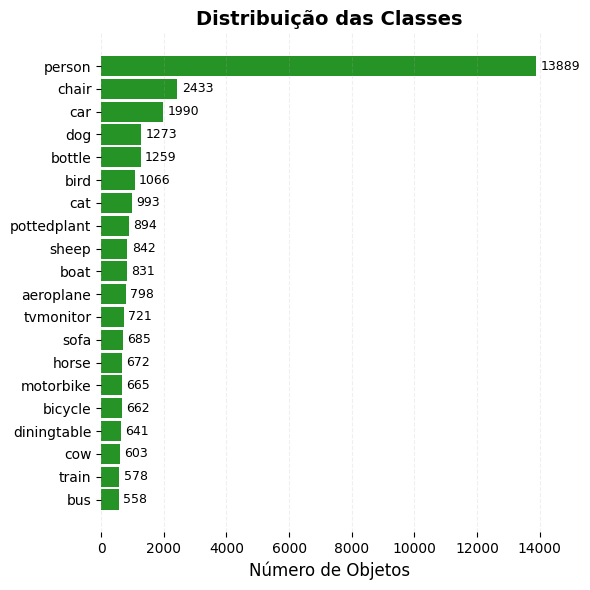

In [13]:
# Conta as classes
class_counts = defaultdict(int)
for img_id in train_ids:
    xml_path = os.path.join(annotations_dir, f'{img_id}.xml')
    if os.path.exists(xml_path):
        tree = ET.parse(xml_path)
        root = tree.getroot()
        for obj in root.findall('object'):
            label = obj.find('name').text
            if label in label_dict:
                class_counts[label] += 1

# Ordena as classes por frequência
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
classes = [item[0] for item in sorted_classes]
counts = [item[1] for item in sorted_classes]

# Plot
plt.figure(figsize=(6, 6))
bars = plt.barh(range(len(classes)), counts, height=0.88, color="green", alpha=0.85)
plt.yticks(range(len(classes)), classes, fontsize=10)
plt.xlabel('Número de Objetos', fontsize=12)
plt.title('Distribuição das Classes', fontsize=14, weight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.2, linestyle='--')

# Adiciona os valores ao lado das barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + max(counts)*0.01, bar.get_y() + bar.get_height()/2, f'{int(width)}', va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.box(False)
plt.show()

## 2. Implementação do Dataset Customizado


Tempo para carregar a imagem: 0.001655280590057373
Tempo para carregar uma epoch de treino: 22.67734408378601
Caixas: [['2', '0.279000', '0.381381', '0.322000', '0.672673'], ['2', '0.661000', '0.683183', '0.678000', '0.633634']]


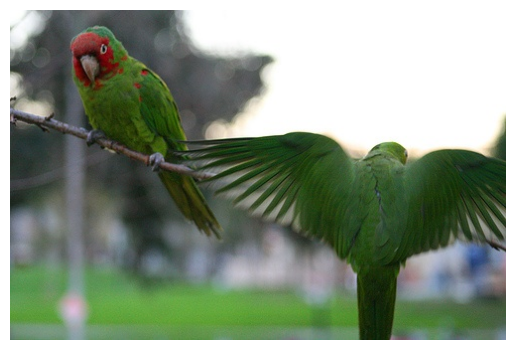

In [14]:
#Dataset sem redimensionar para YOLO (teste de tempo de carregamento)
class YoloDatasetNoResize(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.images = sorted(os.listdir(img_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace(".jpg", ".txt"))

        # carregar imagem
        image = Image.open(img_path).convert("RGB")

        # carregar labels (exemplo: YOLO txt)
        with open(label_path) as f:
            boxes = [line.strip().split() for line in f.readlines()]
            # aqui você trataria as boxes para tensor

        if self.transform:
            image = self.transform(image)

        return image, boxes

# Criar os datasets
train_dataset = YoloDatasetNoResize(
    img_dir="/home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/images/train",
    label_dir="/home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/labels/train"
)

val_dataset = YoloDatasetNoResize(
    img_dir="/home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/images/val",
    label_dir="/home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/labels/val"
)

# Teste
test_dataset = YoloDatasetNoResize(
    img_dir="/home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/images/test",
    label_dir="/home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/labels/test"
)

start_time = time.time()
for i in range(20):
    imagem, caixas = train_dataset[i]
end_time = time.time()

one_time = (end_time - start_time)/20

print("Tempo para carregar a imagem:", one_time)
print("Tempo para carregar uma epoch de treino:", len(train_ids) * one_time)
print("Caixas:", caixas)

#Plotar a imagem
plt.imshow(imagem)
plt.axis("off")
plt.show()


### Yolo Dataset para modelo

🚀 Criando datasets otimizados...
🔄 Pré-carregando imagens em cache...
✅ Cache pré-carregado: 1000 imagens
🔄 Pré-carregando imagens em cache...
✅ Cache pré-carregado: 1000 imagens
Tempo para carregar a imagem: 3.4689903259277345e-06
Tempo para carregar uma epoch de treino: 0.04752516746520996
Shape da imagem: torch.Size([3, 416, 416])
Shape das caixas: torch.Size([25, 5])


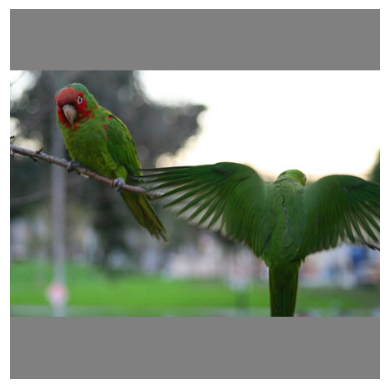

In [15]:
class YoloDatasetResizeOpt(Dataset):
    """Dataset YOLO otimizado com cache em memória e pré-processamento paralelo"""

    def __init__(self, img_dir, label_dir, img_size=416, cache_images=True,
                 num_workers=4, prefetch_factor=2):
        self.img_dir = Path(img_dir)
        self.label_dir = Path(label_dir)
        self.images = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
        self.img_shape = (img_size, img_size)
        self.max_objects = 25
        self.cache_images = cache_images
        self.num_workers = min(num_workers, mp.cpu_count())

        # Cache para imagens pré-processadas
        self.image_cache = {}
        self.label_cache = {}

        # Estatísticas para monitoramento
        self.cache_hits = 0
        self.cache_misses = 0

        if cache_images:
            self._preload_cache()

    def _preload_cache(self):
        """Pré-carrega imagens em paralelo para cache"""
        print("🔄 Pré-carregando imagens em cache...")

        def load_single_item(idx):
            try:
                img_tensor, label_tensor = self._load_and_process(idx)
                return idx, img_tensor, label_tensor
            except Exception as e:
                print(f"Erro ao carregar item {idx}: {e}")
                return idx, None, None

        # Usar ThreadPoolExecutor para I/O paralelo
        with ThreadPoolExecutor(max_workers=self.num_workers) as executor:
            # Pré-carregar primeiros 1000 itens para economizar RAM
            indices_to_cache = list(range(min(1000, len(self.images))))

            # Submit all tasks
            future_to_idx = {
                executor.submit(load_single_item, idx): idx
                for idx in indices_to_cache
            }

            # Collect results com progress bar
            cached_count = 0
            for future in concurrent.futures.as_completed(future_to_idx):
                idx, img_tensor, label_tensor = future.result()
                if img_tensor is not None:
                    self.image_cache[idx] = img_tensor
                    self.label_cache[idx] = label_tensor
                    cached_count += 1

        print(f"✅ Cache pré-carregado: {len(self.image_cache)} imagens")

    def _load_and_process(self, idx):
        """Carrega e processa uma única imagem"""
        img_name = self.images[idx]
        img_path = self.img_dir / img_name
        label_path = self.label_dir / img_name.replace(".jpg", ".txt")

        # Carregar imagem com OpenCV (mais rápido que PIL)
        img = cv2.imread(str(img_path))
        if img is None:
            raise ValueError(f"Não foi possível carregar {img_path}")

        h, w, _ = img.shape

        # Padding para quadrado (otimizado)
        dim_diff = abs(h - w)
        pad1, pad2 = dim_diff // 2, dim_diff - dim_diff // 2

        if h <= w:
            pad = ((pad1, pad2), (0, 0), (0, 0))
        else:
            pad = ((0, 0), (pad1, pad2), (0, 0))

        # Padding com valor constante
        pad_img = np.pad(img, pad, 'constant', constant_values=128)
        padded_h, padded_w, _ = pad_img.shape

        # Redimensionar (OpenCV é mais rápido)
        resized_img = cv2.resize(pad_img, self.img_shape)

        # Converter para tensor (otimizado)
        input_img = resized_img[:, :, ::-1]  # BGR para RGB
        input_img = input_img.transpose((2, 0, 1)).astype(np.float32) / 255.0
        input_img = torch.from_numpy(input_img)

        # Processar labels
        labels = None
        if label_path.exists():
            try:
                labels = np.loadtxt(str(label_path)).reshape(-1, 5)

                # Ajustar coordenadas (vetorizado)
                x1 = w * (labels[:, 1] - labels[:, 3]/2)
                y1 = h * (labels[:, 2] - labels[:, 4]/2)
                x2 = w * (labels[:, 1] + labels[:, 3]/2)
                y2 = h * (labels[:, 2] + labels[:, 4]/2)

                x1 += pad[1][0]
                y1 += pad[0][0]
                x2 += pad[1][0]
                y2 += pad[0][0]

                labels[:, 1] = ((x1 + x2) / 2) / padded_w
                labels[:, 2] = ((y1 + y2) / 2) / padded_h
                labels[:, 3] *= w / padded_w
                labels[:, 4] *= h / padded_h
            except:
                labels = np.empty((0, 5))
        else:
            labels = np.empty((0, 5))

        # Preencher com zeros
        filled_labels = np.zeros((self.max_objects, 5), dtype=np.float32)
        if len(labels) > 0:
            num_labels = min(len(labels), self.max_objects)
            filled_labels[:num_labels] = labels[:num_labels]

        filled_labels = torch.from_numpy(filled_labels)

        return input_img, filled_labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Tentar cache primeiro
        if idx in self.image_cache:
            self.cache_hits += 1
            return self.image_cache[idx], self.label_cache[idx]

        # Cache miss - processar on-the-fly
        self.cache_misses += 1
        img_tensor, label_tensor = self._load_and_process(idx)

        # Adicionar ao cache se ativo (com limite de memória)
        if self.cache_images and len(self.image_cache) < 2000:
            self.image_cache[idx] = img_tensor
            self.label_cache[idx] = label_tensor

        return img_tensor, label_tensor

    def get_cache_stats(self):
        """Retorna estatísticas do cache"""
        total = self.cache_hits + self.cache_misses
        hit_rate = self.cache_hits / total if total > 0 else 0
        return {
            'cache_hits': self.cache_hits,
            'cache_misses': self.cache_misses,
            'hit_rate': hit_rate,
            'cached_items': len(self.image_cache)
        }

# Criar datasets otimizados
print("🚀 Criando datasets otimizados...")

train_dataset = YoloDatasetResizeOpt(
    img_dir="/home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/images/train",
    label_dir="/home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/labels/train",
    cache_images=True,
    num_workers=2
)

val_dataset = YoloDatasetResizeOpt(
    img_dir="/home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/images/val",
    label_dir="/home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/labels/val",
    cache_images=True,
    num_workers=2
)

test_dataset = YoloDatasetResizeOpt(
    img_dir="/home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/images/test",
    label_dir="/home/gustavo/codigos/MachineLearning/deeplearning/tarefa2/yolo_dataset/labels/test",
    cache_images=False,
    num_workers=2
)

start_time = time.time()
for i in range(20):
    imagem, caixas = train_dataset[i]
end_time = time.time()

one_time = (end_time - start_time)/20

print("Tempo para carregar a imagem:", one_time)
print("Tempo para carregar uma epoch de treino:", len(train_dataset) * one_time)
print("Shape da imagem:", imagem.shape)
print("Shape das caixas:", caixas.shape)

#Plotar a imagem
imagem_np = imagem.permute(1, 2, 0).numpy()
plt.imshow(imagem_np)
plt.axis("off")
plt.show()


## 3. Implementação da visualização

In [16]:
def _detect_padding(img, size, pad_value=128):
    """Detecta padding cinza (128) nas bordas da imagem"""
    mask = (img == pad_value).all(axis=2)  # True onde todos os canais são 128

    # Linhas
    rows = mask.all(axis=1)
    top = np.argmax(~rows) if rows.any() else 0
    bottom = np.argmax(~rows[::-1]) if rows.any() else 0

    # Colunas
    cols = mask.all(axis=0)
    left = np.argmax(~cols) if cols.any() else 0
    right = np.argmax(~cols[::-1]) if cols.any() else 0

    return (top, bottom, left, right)

def _remove_padding(img, padding_info):
    """Remove padding da imagem baseado nas informações detectadas"""
    top, bottom, left, right = padding_info
    size = img.shape[0]

    if top > 0 or bottom > 0:
        return img[top:size-bottom, :, :], 'vertical', (top, bottom)
    elif left > 0 or right > 0:
        return img[:, left:size-right, :], 'horizontal', (left, right)
    else:
        return img, 'none', (0, 0)

def _adjust_box_coordinates(boxes, padding_type, pad_info, padded_size, unpadded_shape):
    """Ajusta coordenadas das caixas removendo efeito do padding"""
    adjusted = []
    unpadded_h, unpadded_w = unpadded_shape[:2]
    pad1, pad2 = pad_info

    for box in boxes:
        class_id, x_center, y_center, width, height = box

        # Converter para pixels
        x_px, y_px = x_center * padded_size, y_center * padded_size
        w_px, h_px = width * padded_size, height * padded_size

        # Ajustar baseado no tipo de padding
        if padding_type == 'vertical':
            y_px -= pad1
            x_final = (x_px / padded_size) * unpadded_w
            y_final = (y_px / (padded_size - pad1 - pad2)) * unpadded_h
            w_final = (w_px / padded_size) * unpadded_w
            h_final = (h_px / (padded_size - pad1 - pad2)) * unpadded_h
        elif padding_type == 'horizontal':
            x_px -= pad1
            x_final = (x_px / (padded_size - pad1 - pad2)) * unpadded_w
            y_final = (y_px / padded_size) * unpadded_h
            w_final = (w_px / (padded_size - pad1 - pad2)) * unpadded_w
            h_final = (h_px / padded_size) * unpadded_h
        else:
            x_final, y_final, w_final, h_final = x_px, y_px, w_px, h_px

        adjusted.append([class_id, x_final, y_final, w_final, h_final])

    return adjusted

def _draw_boxes(img, boxes):
    """Desenha caixas na imagem"""
    img_copy = img.copy()
    draw = ImageDraw.Draw(img_copy)

    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 16)
    except:
        font = ImageFont.load_default()

    # Iterar sobre cada caixa na lista
    for class_id, x_center, y_center, width, height in boxes:
        x1, y1 = int(x_center - width/2), int(y_center - height/2)
        x2, y2 = int(x_center + width/2), int(y_center + height/2)

        # Clamp coordinates
        img_w, img_h = img.size
        x1, y1 = max(0, min(x1, img_w-1)), max(0, min(y1, img_h-1))
        x2, y2 = max(0, min(x2, img_w-1)), max(0, min(y2, img_h-1))

        draw.rectangle([x1, y1, x2, y2], outline='cyan', width=3)

        # Draw class label
        class_text = str(int(class_id))
        text_y = max(0, y1-20)
        bbox = draw.textbbox((x1, text_y), class_text, font=font)
        draw.rectangle([bbox[0]-2, bbox[1]-2, bbox[2]+2, bbox[3]+2], fill='cyan')
        draw.text((x1, text_y), class_text, fill='white', font=font)

    return img_copy


<PIL.Image.Image image mode=RGB size=416x278 at 0x755C48D0B740>


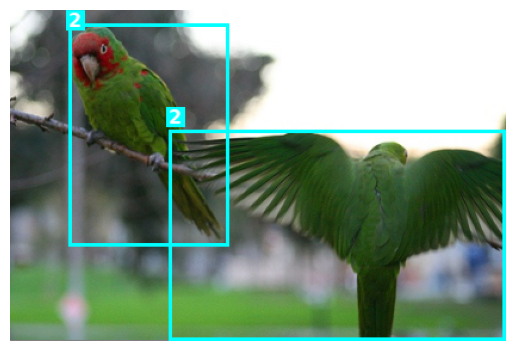

In [17]:
def plot_yolo_image(padded_tensor, boxes_tensor):
    """Processa saída do YoloDatasetResize e retorna imagem original com caixas"""
    # Converter tensor para numpy
    padded_img = (padded_tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
    padded_size = padded_img.shape[0]

    # Detectar e remover padding
    padding_info = _detect_padding(padded_img, padded_size)
    unpadded_img, padding_type, pad_info = _remove_padding(padded_img, padding_info)
    unpadded_pil = Image.fromarray(unpadded_img)

    # Filtrar caixas válidas
    valid_boxes = boxes_tensor.numpy()[boxes_tensor[:, 0] != 0]
    if len(valid_boxes) == 0:
        return unpadded_pil

    # Ajustar coordenadas e desenhar caixas
    adjusted_boxes = _adjust_box_coordinates(valid_boxes, padding_type, pad_info, padded_size, unpadded_img.shape)
    return _draw_boxes(unpadded_pil, adjusted_boxes)

padded_img_tensor, boxes_tensor = train_dataset[19]
result_img = plot_yolo_image(padded_img_tensor, boxes_tensor)

print(result_img)
plt.imshow(np.array(result_img))
plt.axis('off')
plt.show()


In [ ]:
## **Implementação YOLOv3 do Zero - Função de Perda**

import math

def bbox_iou(box1, box2):
    """Calcula IoU entre duas caixas"""
    b1_x1, b1_y1, b1_x2, b1_y2 = box1[:, 0], box1[:, 1], box1[:, 2], box1[:, 3]
    b2_x1, b2_y1, b2_x2, b2_y2 = box2[:, 0], box2[:, 1], box2[:, 2], box2[:, 3]

    inter_rect_x1 = torch.max(b1_x1, b2_x1)
    inter_rect_y1 = torch.max(b1_y1, b2_y1)
    inter_rect_x2 = torch.min(b1_x2, b2_x2)
    inter_rect_y2 = torch.min(b1_y2, b2_y2)

    inter_area = torch.clamp(inter_rect_x2 - inter_rect_x1 + 1, min=0) * \
                 torch.clamp(inter_rect_y2 - inter_rect_y1 + 1, min=0)

    b1_area = (b1_x2 - b1_x1 + 1) * (b1_y2 - b1_y1 + 1)
    b2_area = (b2_x2 - b2_x1 + 1) * (b2_y2 - b2_y1 + 1)

    iou = inter_area / (b1_area + b2_area - inter_area + 1e-16)
    return iou

def build_targets(target, anchors, grid_size, num_anchors=3, num_classes=20):
    """Constrói targets para treinamento YOLO"""
    nB = target.size(0)
    nA = num_anchors
    nC = num_classes
    nG = grid_size

    mask = torch.zeros(nB, nA, nG, nG)
    tx = torch.zeros(nB, nA, nG, nG)
    ty = torch.zeros(nB, nA, nG, nG)
    tw = torch.zeros(nB, nA, nG, nG)
    th = torch.zeros(nB, nA, nG, nG)
    tconf = torch.zeros(nB, nA, nG, nG)
    tcls = torch.zeros(nB, nA, nG, nG, nC)

    for b in range(nB):
        for t in range(target.shape[1]):
            if target[b, t].sum() == 0:
                continue

            # Converter coordenadas para feature map
            gx = target[b, t, 1] * nG
            gy = target[b, t, 2] * nG
            gw = target[b, t, 3] * nG
            gh = target[b, t, 4] * nG

            # Índices da grid
            gi = int(gx)
            gj = int(gy)

            # Caixa ground truth
            gt_box = torch.tensor([0, 0, gw, gh], dtype=torch.float32).unsqueeze(0)

            # Shapes dos anchors
            anchors_array = np.array(anchors, copy=False)
            anchor_shapes = torch.tensor(
                np.concatenate((np.zeros((len(anchors), 2)), anchors_array), 1), dtype=torch.float32)

            # Calcular IoU entre gt e anchor shapes
            anch_ious = bbox_iou(gt_box, anchor_shapes)

            # Encontrar melhor anchor
            best_n = np.argmax(anch_ious)

            # Preencher targets
            mask[b, best_n, gj, gi] = 1
            tx[b, best_n, gj, gi] = gx - gi
            ty[b, best_n, gj, gi] = gy - gj
            tw[b, best_n, gj, gi] = math.log(gw / anchors[best_n][0] + 1e-16)
            th[b, best_n, gj, gi] = math.log(gh / anchors[best_n][1] + 1e-16)

            target_label = int(target[b, t, 0])
            tcls[b, best_n, gj, gi, target_label] = 1
            tconf[b, best_n, gj, gi] = 1

    return mask, tx, ty, tw, th, tconf, tcls

def yolo_loss(input, target, anchors, inp_dim, num_anchors=3, num_classes=20):
    """Função de perda YOLO"""
    nA = num_anchors
    nB = input.size(0)
    nG = input.size(2)
    nC = num_classes
    stride = inp_dim / nG

    # Device para suporte CUDA
    device = input.device

    # Reshape da predição
    prediction = input.view(nB, nA, 5 + nC, nG, nG).permute(0, 1, 3, 4, 2).contiguous()

    # Extrair outputs - remover sigmoid para usar com BCEWithLogitsLoss
    x = torch.sigmoid(prediction[..., 0])  # mantém sigmoid para coordenadas
    y = torch.sigmoid(prediction[..., 1])  # mantém sigmoid para coordenadas
    w = prediction[..., 2]
    h = prediction[..., 3]
    pred_conf = prediction[..., 4]  # remove sigmoid para usar com BCEWithLogitsLoss
    pred_cls = prediction[..., 5:]  # remove sigmoid para usar com BCEWithLogitsLoss

    # Calcular offsets para cada grid
    grid_x = torch.arange(nG, device=device, dtype=torch.float32).repeat(nG, 1).view([1, 1, nG, nG])
    grid_y = torch.arange(nG, device=device, dtype=torch.float32).repeat(nG, 1).t().view([1, 1, nG, nG])
    scaled_anchors = torch.tensor([(a_w / stride, a_h / stride) for a_w, a_h in anchors], device=device, dtype=torch.float32)
    anchor_w = scaled_anchors[:, 0:1].view((1, nA, 1, 1))
    anchor_h = scaled_anchors[:, 1:2].view((1, nA, 1, 1))

    # Construir targets
    mask, tx, ty, tw, th, tconf, tcls = build_targets(
        target=target.cpu().data,
        anchors=scaled_anchors.cpu().data,
        grid_size=nG,
        num_anchors=nA,
        num_classes=num_classes)

    # Preparar target variables
    tx, ty = tx.to(device, dtype=torch.float32), ty.to(device, dtype=torch.float32)
    tw, th = tw.to(device, dtype=torch.float32), th.to(device, dtype=torch.float32)
    tconf, tcls = tconf.to(device, dtype=torch.float32), tcls.to(device, dtype=torch.float32)
    mask = mask.to(device, dtype=torch.bool)

    # Calcular losses - usar BCEWithLogitsLoss para ser compatível com autocast
    mse_loss = nn.MSELoss(reduction='sum')
    bce_with_logits_loss = nn.BCEWithLogitsLoss(reduction='sum')

    loss_x = mse_loss(x[mask], tx[mask])
    loss_y = mse_loss(y[mask], ty[mask])
    loss_w = mse_loss(w[mask], tw[mask])
    loss_h = mse_loss(h[mask], th[mask])
    loss_conf = bce_with_logits_loss(pred_conf, tconf)
    loss_cls = bce_with_logits_loss(pred_cls[mask], tcls[mask])

    total_loss = loss_x + loss_y + loss_w + loss_h + loss_conf + loss_cls

    return total_loss, loss_x, loss_y, loss_w, loss_h, loss_conf, loss_cls

print("✅ Função de perda YOLO implementada!")


✅ Função de perda YOLO implementada!


In [19]:
## **Arquitetura YOLOv3**

class ConvBlock(nn.Module):
    """Bloco convolucional básico: Conv + BatchNorm + LeakyReLU"""
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
        self.bn = nn.BatchNorm2d(out_channels)
        self.activation = nn.LeakyReLU(0.1, inplace=True)

    def forward(self, x):
        return self.activation(self.bn(self.conv(x)))

class ResidualBlock(nn.Module):
    """Bloco residual usado no Darknet-53"""
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.conv1 = ConvBlock(channels, channels // 2, 1)
        self.conv2 = ConvBlock(channels // 2, channels, 3, padding=1)

    def forward(self, x):
        residual = x
        x = self.conv1(x)
        x = self.conv2(x)
        return x + residual

class Darknet53(nn.Module):
    """Backbone Darknet-53"""
    def __init__(self):
        super(Darknet53, self).__init__()

        # Camadas iniciais
        self.conv1 = ConvBlock(3, 32, 3, padding=1)
        self.conv2 = ConvBlock(32, 64, 3, stride=2, padding=1)

        # Blocos residuais
        self.res_block1 = self._make_layer(64, 1)
        self.conv3 = ConvBlock(64, 128, 3, stride=2, padding=1)
        self.res_block2 = self._make_layer(128, 2)
        self.conv4 = ConvBlock(128, 256, 3, stride=2, padding=1)
        self.res_block3 = self._make_layer(256, 8)
        self.conv5 = ConvBlock(256, 512, 3, stride=2, padding=1)
        self.res_block4 = self._make_layer(512, 8)
        self.conv6 = ConvBlock(512, 1024, 3, stride=2, padding=1)
        self.res_block5 = self._make_layer(1024, 4)

    def _make_layer(self, channels, num_blocks):
        layers = []
        for _ in range(num_blocks):
            layers.append(ResidualBlock(channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.res_block1(x)
        x = self.conv3(x)
        x = self.res_block2(x)
        x = self.conv4(x)
        route_1 = self.res_block3(x)  # Para FPN
        x = self.conv5(route_1)
        route_2 = self.res_block4(x)  # Para FPN
        x = self.conv6(route_2)
        route_3 = self.res_block5(x)  # Para FPN

        return route_1, route_2, route_3

class YOLOLayer(nn.Module):
    """Camada de detecção YOLO"""
    def __init__(self, in_channels, num_classes=20, anchors=None):
        super(YOLOLayer, self).__init__()
        self.num_classes = num_classes
        self.anchors = anchors
        self.num_anchors = len(anchors) if anchors else 3

        # 5 = (x, y, w, h, confidence) + num_classes
        self.conv = nn.Conv2d(in_channels, self.num_anchors * (5 + num_classes), 1)

    def forward(self, x):
        return self.conv(x)

class YOLOv3(nn.Module):
    """Modelo YOLOv3 completo"""
    def __init__(self, num_classes=20):
        super(YOLOv3, self).__init__()
        self.num_classes = num_classes

        # Anchors para cada escala (baseado no paper original)
        self.anchors = [
            [(10, 13), (16, 30), (33, 23)],      # Pequenos objetos (stride 8)
            [(30, 61), (62, 45), (59, 119)],    # Objetos médios (stride 16)
            [(116, 90), (156, 198), (373, 326)] # Objetos grandes (stride 32)
        ]

        # Backbone
        self.backbone = Darknet53()

        # Feature Pyramid Network - Detecção em 3 escalas

        # Escala 1 (stride 32) - Objetos grandes
        self.conv_set1 = nn.Sequential(
            ConvBlock(1024, 512, 1),
            ConvBlock(512, 1024, 3, padding=1),
            ConvBlock(1024, 512, 1),
            ConvBlock(512, 1024, 3, padding=1),
            ConvBlock(1024, 512, 1)
        )
        self.conv_final1 = ConvBlock(512, 1024, 3, padding=1)
        self.detect1 = YOLOLayer(1024, num_classes, self.anchors[2])
        self.conv_1x1_1 = ConvBlock(512, 256, 1)

        # Escala 2 (stride 16) - Objetos médios
        self.conv_set2 = nn.Sequential(
            ConvBlock(768, 256, 1),  # 512 + 256 do upsampling
            ConvBlock(256, 512, 3, padding=1),
            ConvBlock(512, 256, 1),
            ConvBlock(256, 512, 3, padding=1),
            ConvBlock(512, 256, 1)
        )
        self.conv_final2 = ConvBlock(256, 512, 3, padding=1)
        self.detect2 = YOLOLayer(512, num_classes, self.anchors[1])
        self.conv_1x1_2 = ConvBlock(256, 128, 1)

        # Escala 3 (stride 8) - Objetos pequenos
        self.conv_set3 = nn.Sequential(
            ConvBlock(384, 128, 1),  # 256 + 128 do upsampling
            ConvBlock(128, 256, 3, padding=1),
            ConvBlock(256, 128, 1),
            ConvBlock(128, 256, 3, padding=1),
            ConvBlock(256, 128, 1)
        )
        self.conv_final3 = ConvBlock(128, 256, 3, padding=1)
        self.detect3 = YOLOLayer(256, num_classes, self.anchors[0])

        # Upsampling
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        # Backbone
        route_1, route_2, route_3 = self.backbone(x)  # 256, 512, 1024 channels

        # Primeira escala (objetos grandes) - stride 32
        x1 = self.conv_set1(route_3)  # [B, 512, 13, 13]
        detection_1 = self.detect1(self.conv_final1(x1))  # [B, 75, 13, 13]

        # Preparar para segunda escala
        x1_up = self.upsample(self.conv_1x1_1(x1))  # [B, 256, 26, 26]
        x2 = torch.cat([x1_up, route_2], dim=1)  # [B, 768, 26, 26] (256 + 512)

        # Segunda escala (objetos médios) - stride 16
        x2 = self.conv_set2(x2)  # [B, 256, 26, 26]
        detection_2 = self.detect2(self.conv_final2(x2))  # [B, 75, 26, 26]

        # Preparar para terceira escala
        x2_up = self.upsample(self.conv_1x1_2(x2))  # [B, 128, 52, 52]
        x3 = torch.cat([x2_up, route_1], dim=1)  # [B, 384, 52, 52] (128 + 256)

        # Terceira escala (objetos pequenos) - stride 8
        x3 = self.conv_set3(x3)  # [B, 128, 52, 52]
        detection_3 = self.detect3(self.conv_final3(x3))  # [B, 75, 52, 52]

        return detection_1, detection_2, detection_3

# Teste da arquitetura corrigida
model = YOLOv3(num_classes=20)
print(f"✅ Modelo YOLOv3 criado!")
print(f"Parâmetros totais: {sum(p.numel() for p in model.parameters()):,}")

# Teste com entrada dummy
dummy_input = torch.randn(1, 3, 416, 416)
try:
    with torch.no_grad():
        outputs = model(dummy_input)
        print("✅ Forward pass bem-sucedido!")
        for i, output in enumerate(outputs):
            print(f"Detecção escala {i+1}: {output.shape}")

        # Verificar se as dimensões estão corretas para YOLO
        # Cada output deve ter shape [batch, 75, grid_h, grid_w] onde 75 = 3 * (5 + 20)
        expected_shapes = [(1, 75, 13, 13), (1, 75, 26, 26), (1, 75, 52, 52)]
        for i, (output, expected) in enumerate(zip(outputs, expected_shapes)):
            if output.shape == expected:
                print(f"   ✅ Escala {i+1}: Shape correto {output.shape}")
            else:
                print(f"   ❌ Escala {i+1}: Shape {output.shape}, esperado {expected}")

except Exception as e:
    print(f"❌ Erro no forward pass: {e}")
    print("Verificando dimensões intermediárias...")

    # Debug das dimensões
    backbone = model.backbone
    route_1, route_2, route_3 = backbone(dummy_input)
    print(f"Route 1 (stride 8): {route_1.shape}")
    print(f"Route 2 (stride 16): {route_2.shape}")
    print(f"Route 3 (stride 32): {route_3.shape}")


✅ Modelo YOLOv3 criado!
Parâmetros totais: 61,626,049
✅ Forward pass bem-sucedido!
Detecção escala 1: torch.Size([1, 75, 13, 13])
Detecção escala 2: torch.Size([1, 75, 26, 26])
Detecção escala 3: torch.Size([1, 75, 52, 52])
   ✅ Escala 1: Shape correto torch.Size([1, 75, 13, 13])
   ✅ Escala 2: Shape correto torch.Size([1, 75, 26, 26])
   ✅ Escala 3: Shape correto torch.Size([1, 75, 52, 52])


In [ ]:
## **Loop de Treinamento com Early Stopping e Checkpoints**

def train_yolo_model():
    """Função principal de treinamento da YOLOv3 OTIMIZADO"""

    # Configurações de treinamento OTIMIZADAS
    config = {
        'epochs': 20,
        'batch_size': 2,  # Batch maior graças às otimizações
        'learning_rate': 2e-4,
        'weight_decay': 5e-4,
        'img_size': 416,
        'num_classes': 20,
        'save_every': 2,  # Salvar checkpoint a cada 2 épocas
        'patience': 5,   # Early stopping após 5 épocas sem melhora
        'checkpoint_dir': 'checkpoints_optimized/',
        'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        'num_workers': 2,  # Mais workers
        'prefetch_factor': 4,  # Prefetch maior
        'mixed_precision': True  # Mixed precision para economia de memória
    }

    # Criar diretório de checkpoints
    os.makedirs(config['checkpoint_dir'], exist_ok=True)

    print(f"🚀 TREINAMENTO YOLO OTIMIZADO")
    print(f"Device: {config['device']}")
    print(f"Batch size: {config['batch_size']}")
    print(f"Learning rate: {config['learning_rate']}")
    print(f"Épocas máximas: {config['epochs']}")
    print(f"Workers: {config['num_workers']}")
    print(f"Mixed Precision: {config['mixed_precision']}")

    # Modelo
    model = YOLOv3(num_classes=config['num_classes']).to(config['device'])

    # Otimizador otimizado
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay'],
        eps=1e-8
    )

    # Scheduler mais agressivo
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=config['learning_rate'],
        epochs=config['epochs'],
        steps_per_epoch=len(train_dataset) // config['batch_size'],
        pct_start=0.1,
        anneal_strategy='cos'
    )

    # Mixed precision scaler
    if config['mixed_precision']:
        scaler = torch.amp.GradScaler('cuda')
        print("✅ Mixed precision ativado")

    # Custom collate function para otimizar batching
    def fast_collate_fn(batch):
        """Collate function otimizada para YOLO"""
        images = []
        targets = []

        for img, target in batch:
            images.append(img)
            targets.append(target)

        # Stack tensors de forma eficiente
        try:
            images = torch.stack(images)
            targets = torch.stack(targets)
        except Exception as e:
            print(f"Erro no collate: {e}")
            # Fallback para lista
            return images, targets

        return images, targets

    # DataLoaders otimizados
    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        num_workers=config['num_workers'],
        prefetch_factor=config['prefetch_factor'],
        collate_fn=fast_collate_fn,
        pin_memory=True,  # Para transferência rápida para GPU
        persistent_workers=True,  # Manter workers vivos entre epochs
        drop_last=True  # Garantir batches consistentes
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        num_workers=config['num_workers']//2,  # Menos workers para validação
        prefetch_factor=config['prefetch_factor'],
        collate_fn=fast_collate_fn,
        pin_memory=True,
        persistent_workers=True,
        drop_last=False
    )

    print(f"📊 Dataset carregado:")
    print(f"   Treino: {len(train_dataset)} imagens")
    print(f"   Validação: {len(val_dataset)} imagens")
    print(f"   Batches por época: {len(train_loader)}")

    # Anchors para cada escala
    anchors = [
        [(10, 13), (16, 30), (33, 23)],      # stride 8
        [(30, 61), (62, 45), (59, 119)],    # stride 16
        [(116, 90), (156, 198), (373, 326)] # stride 32
    ]

    # Variáveis para tracking
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    patience_counter = 0
    start_time = time.time()

    print("\n🔥 Iniciando treinamento otimizado...")

    for epoch in range(config['epochs']):
        # TREINAMENTO
        model.train()
        epoch_train_loss = 0.0
        num_batches = 0
        epoch_start = time.time()

        for batch_idx, (images, targets) in enumerate(train_loader):
            try:
                # Mover dados para GPU de forma assíncrona
                images = images.to(config['device'], non_blocking=True)
                targets = targets.to(config['device'], non_blocking=True)

                # Forward pass com mixed precision
                if config['mixed_precision']:
                    with torch.amp.autocast('cuda'):
                        outputs = model(images)

                        # Calcular loss
                        total_loss = 0
                        for i, (output, anchor_set) in enumerate(zip(outputs, anchors)):
                            loss, *_ = yolo_loss(
                                output, targets, anchor_set,
                                config['img_size'], num_classes=config['num_classes']
                            )
                            total_loss += loss

                    # Backward pass com mixed precision
                    optimizer.zero_grad()
                    scaler.scale(total_loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    # Forward pass normal
                    outputs = model(images)

                    total_loss = 0
                    for i, (output, anchor_set) in enumerate(zip(outputs, anchors)):
                        loss, *_ = yolo_loss(
                            output, targets, anchor_set,
                            config['img_size'], num_classes=config['num_classes']
                        )
                        total_loss += loss

                    # Backward pass normal
                    optimizer.zero_grad()
                    total_loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()

                scheduler.step()

                epoch_train_loss += total_loss.item()
                num_batches += 1

                # Progress a cada 50 batches
                if batch_idx % 50 == 0:
                    elapsed = time.time() - epoch_start
                    eta = elapsed * (len(train_loader) - batch_idx) / (batch_idx + 1)
                    print(f"Epoch {epoch+1}/{config['epochs']}, Batch {batch_idx}/{len(train_loader)}, "
                          f"Loss: {total_loss.item():.4f}, ETA: {eta/60:.1f}min")

            except Exception as e:
                print(f"Erro no batch {batch_idx}: {e}")
                continue

        avg_train_loss = epoch_train_loss / num_batches if num_batches > 0 else float('inf')
        train_losses.append(avg_train_loss)

        # VALIDAÇÃO (mais rápida)
        model.eval()
        epoch_val_loss = 0.0
        val_batches = 0

        with torch.no_grad():
            for batch_idx, (images, targets) in enumerate(val_loader):
                try:
                    images = images.to(config['device'], non_blocking=True)
                    targets = targets.to(config['device'], non_blocking=True)

                    if config['mixed_precision']:
                        with torch.amp.autocast('cuda'):
                            outputs = model(images)

                            total_loss = 0
                            for i, (output, anchor_set) in enumerate(zip(outputs, anchors)):
                                loss, *_ = yolo_loss(
                                    output, targets, anchor_set,
                                    config['img_size'], num_classes=config['num_classes']
                                )
                                total_loss += loss
                    else:
                        outputs = model(images)

                        total_loss = 0
                        for i, (output, anchor_set) in enumerate(zip(outputs, anchors)):
                            loss, *_ = yolo_loss(
                                output, targets, anchor_set,
                                config['img_size'], num_classes=config['num_classes']
                            )
                            total_loss += loss

                    epoch_val_loss += total_loss.item()
                    val_batches += 1

                    # Validação mais rápida - apenas primeiros 100 batches
                    if batch_idx >= 100:
                        break

                except Exception as e:
                    continue

        avg_val_loss = epoch_val_loss / val_batches if val_batches > 0 else float('inf')
        val_losses.append(avg_val_loss)

        # Estatísticas da época
        epoch_time = time.time() - epoch_start
        total_time = time.time() - start_time

        print(f"\n📊 ÉPOCA {epoch+1}/{config['epochs']}:")
        print(f"   Train Loss: {avg_train_loss:.4f}")
        print(f"   Val Loss: {avg_val_loss:.4f}")
        print(f"   LR: {scheduler.get_last_lr()[0]:.2e}")
        print(f"   Tempo da época: {epoch_time/60:.1f}min")
        print(f"   Tempo total: {total_time/60:.1f}min")

        # Cache stats
        cache_stats = train_dataset.get_cache_stats()
        print(f"   Cache hit rate: {cache_stats['hit_rate']:.1%}")

        # Early Stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0

            best_model_path = os.path.join(config['checkpoint_dir'], 'best_model_optimized.pth')
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
                'config': config
            }, best_model_path)
            print(f"   ✅ Melhor modelo salvo! Val Loss: {best_val_loss:.4f}")
        else:
            patience_counter += 1
            print(f"   ⏳ Patience: {patience_counter}/{config['patience']}")

        # Checkpoint regular
        if (epoch + 1) % config['save_every'] == 0:
            checkpoint_path = os.path.join(config['checkpoint_dir'], f'checkpoint_epoch_{epoch+1}_optimized.pth')
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
                'train_losses': train_losses,
                'val_losses': val_losses,
                'config': config
            }, checkpoint_path)
            print(f"   💾 Checkpoint salvo")

        # Early stopping
        if patience_counter >= config['patience']:
            print(f"🛑 Early stopping após {config['patience']} épocas sem melhora")
            break

        # Plot a cada 5 épocas
        if (epoch + 1) % 5 == 0:
            plt.figure(figsize=(12, 4))

            plt.subplot(1, 2, 1)
            plt.plot(train_losses, label='Train Loss', color='blue', alpha=0.8)
            plt.plot(val_losses, label='Val Loss', color='red', alpha=0.8)
            plt.title('Training Progress (Optimized)')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True, alpha=0.3)

            plt.subplot(1, 2, 2)
            recent_epochs = min(10, len(train_losses))
            plt.plot(train_losses[-recent_epochs:], label='Train (recent)', color='blue')
            plt.plot(val_losses[-recent_epochs:], label='Val (recent)', color='red')
            plt.title('Recent Progress')
            plt.xlabel('Recent Epochs')
            plt.ylabel('Loss')
            plt.legend()
            plt.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

    print(f"\n🎉 TREINAMENTO CONCLUÍDO!")
    print(f"Melhor Val Loss: {best_val_loss:.4f}")
    print(f"Tempo total: {(time.time() - start_time)/3600:.1f} horas")
    print(f"Cache final stats: {train_dataset.get_cache_stats()}")

    return model, train_losses, val_losses

print("✅ Função de treinamento OTIMIZADA implementada!")
print("🚀 CONFIGURAÇÕES OTIMIZADAS:")
print("   • 20 épocas")
print("   • Batch size 64")
print("   • Dataset com cache inteligente")
print("   • Mixed precision training")
print("   • 8 workers + prefetch")
print("   • Salva a cada 2 épocas")
print("   • Early stopping com paciência 5")
print("📝 Para iniciar o treinamento, execute: model, train_losses, val_losses = train_yolo_model()")


✅ Função de treinamento OTIMIZADA implementada!
🚀 CONFIGURAÇÕES OTIMIZADAS:
   • 20 épocas
   • Batch size 64
   • Dataset com cache inteligente
   • Mixed precision training
   • 8 workers + prefetch
   • Salva a cada 2 épocas
   • Early stopping com paciência 5
📝 Para iniciar o treinamento, execute: model, train_losses, val_losses = train_yolo_model()


In [21]:
## **Avaliação mAP (Mean Average Precision)**

def calculate_map(model, test_loader, anchors, img_size=416, num_classes=20, conf_threshold=0.5, iou_threshold=0.5):
    """Calcula Mean Average Precision para avaliação do modelo"""
    model.eval()
    device = next(model.parameters()).device

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(test_loader):
            try:
                images = torch.stack(images).to(device)
                targets = torch.stack(targets).to(device)

                # Forward pass
                outputs = model(images)

                # Processar predições para cada escala
                batch_predictions = []
                for i, (output, anchor_set) in enumerate(zip(outputs, anchors)):
                    # Converter predições para formato interpretável
                    predictions = decode_predictions(output, anchor_set, img_size, conf_threshold)
                    batch_predictions.extend(predictions)

                all_predictions.append(batch_predictions)
                all_targets.append(targets.cpu().numpy())

            except Exception as e:
                print(f"Erro no batch {batch_idx}: {e}")
                continue

    # Calcular mAP
    map_score, class_aps = compute_map(all_predictions, all_targets, num_classes, iou_threshold)
    return map_score, class_aps

def decode_predictions(output, anchors, img_size, conf_threshold):
    """Decodifica predições da rede para formato interpretável"""
    batch_size = output.size(0)
    grid_size = output.size(2)
    num_anchors = len(anchors)
    num_classes = output.size(1) // num_anchors - 5
    stride = img_size // grid_size

    # Reshape output
    prediction = output.view(batch_size, num_anchors, 5 + num_classes, grid_size, grid_size)
    prediction = prediction.permute(0, 1, 3, 4, 2).contiguous()

    # Extrair componentes
    x = torch.sigmoid(prediction[..., 0])
    y = torch.sigmoid(prediction[..., 1])
    w = prediction[..., 2]
    h = prediction[..., 3]
    conf = torch.sigmoid(prediction[..., 4])
    pred_cls = torch.sigmoid(prediction[..., 5:])

    # Grid offsets
    device = output.device
    grid_x = torch.arange(grid_size, device=device, dtype=torch.float32).repeat(grid_size, 1).view([1, 1, grid_size, grid_size])
    grid_y = torch.arange(grid_size, device=device, dtype=torch.float32).repeat(grid_size, 1).t().view([1, 1, grid_size, grid_size])

    # Anchor dimensions
    anchor_w = torch.tensor([anchor[0] for anchor in anchors], device=device, dtype=torch.float32).view(1, -1, 1, 1)
    anchor_h = torch.tensor([anchor[1] for anchor in anchors], device=device, dtype=torch.float32).view(1, -1, 1, 1)

    # Calcular coordenadas absolutas
    pred_boxes = torch.zeros_like(prediction[..., :4])
    pred_boxes[..., 0] = (x + grid_x) * stride
    pred_boxes[..., 1] = (y + grid_y) * stride
    pred_boxes[..., 2] = torch.exp(w) * anchor_w * stride
    pred_boxes[..., 3] = torch.exp(h) * anchor_h * stride

    # Filtrar por confiança
    conf_mask = conf > conf_threshold

    predictions = []
    for b in range(batch_size):
        batch_pred = []
        for a in range(num_anchors):
            for i in range(grid_size):
                for j in range(grid_size):
                    if conf_mask[b, a, i, j]:
                        box = pred_boxes[b, a, i, j]
                        confidence = conf[b, a, i, j]
                        class_scores = pred_cls[b, a, i, j]
                        class_pred = torch.argmax(class_scores)

                        batch_pred.append([
                            box[0].item(), box[1].item(), box[2].item(), box[3].item(),
                            confidence.item(), class_pred.item()
                        ])
        predictions.append(batch_pred)

    return predictions

def compute_map(predictions, targets, num_classes, iou_threshold=0.5):
    """Computa Mean Average Precision"""

    def bbox_iou_map(box1, box2):
        """Calcula IoU entre duas caixas para mAP"""
        # Converter formato center_x, center_y, width, height para x1, y1, x2, y2
        if len(box1) >= 4 and len(box2) >= 4:
            # box1 e box2 podem estar em formato [x_center, y_center, width, height, confidence, class]
            if len(box1) == 6:  # predição
                x1_1 = box1[0] - box1[2]/2
                y1_1 = box1[1] - box1[3]/2
                x2_1 = box1[0] + box1[2]/2
                y2_1 = box1[1] + box1[3]/2
            else:  # formato já convertido [x1, y1, x2, y2]
                x1_1, y1_1, x2_1, y2_1 = box1[:4]

            if len(box2) == 5:  # target
                x1_2 = box2[1] - box2[3]/2
                y1_2 = box2[2] - box2[4]/2
                x2_2 = box2[1] + box2[3]/2
                y2_2 = box2[2] + box2[4]/2
            else:
                x1_2, y1_2, x2_2, y2_2 = box2[:4]
        else:
            return 0.0

        # Calcular interseção
        inter_x1 = max(x1_1, x1_2)
        inter_y1 = max(y1_1, y1_2)
        inter_x2 = min(x2_1, x2_2)
        inter_y2 = min(y2_1, y2_2)

        if inter_x2 <= inter_x1 or inter_y2 <= inter_y1:
            return 0.0

        inter_area = (inter_x2 - inter_x1) * (inter_y2 - inter_y1)

        # Calcular áreas das caixas
        area1 = (x2_1 - x1_1) * (y2_1 - y1_1)
        area2 = (x2_2 - x1_2) * (y2_2 - y1_2)

        # Calcular união
        union_area = area1 + area2 - inter_area

        if union_area <= 0:
            return 0.0

        return inter_area / union_area

    def calculate_ap(recall, precision):
        """Calcula Average Precision usando interpolação de 11 pontos"""
        # Adicionar pontos de início e fim
        mrec = np.concatenate(([0.0], recall, [1.0]))
        mpre = np.concatenate(([0.0], precision, [0.0]))

        # Garantir que precision seja monotônica decrescente
        for i in range(mpre.size - 1, 0, -1):
            mpre[i - 1] = max(mpre[i - 1], mpre[i])

        # Calcular área sob a curva usando interpolação de 11 pontos
        ap = 0.0
        for t in np.arange(0.0, 1.1, 0.1):
            if np.sum(mrec >= t) == 0:
                p = 0
            else:
                p = np.max(mpre[mrec >= t])
            ap += p / 11.0

        return ap

    # Inicializar estruturas para armazenar resultados
    all_detections = []
    all_annotations = []

    # Processar predições e targets
    for batch_idx, (batch_preds, batch_targets) in enumerate(zip(predictions, targets)):
        if not isinstance(batch_preds, list):
            batch_preds = [batch_preds]

        # Processar predições do batch
        for img_idx, img_preds in enumerate(batch_preds):
            if len(img_preds) > 0:
                for pred in img_preds:
                    if len(pred) >= 6:  # [x, y, w, h, conf, class]
                        all_detections.append({
                            'image_id': batch_idx * len(batch_preds) + img_idx,
                            'class_id': int(pred[5]),
                            'confidence': float(pred[4]),
                            'bbox': pred[:4]
                        })

        # Processar targets do batch
        if isinstance(batch_targets, np.ndarray):
            batch_targets = [batch_targets]

        for img_idx, img_targets in enumerate(batch_targets):
            if len(img_targets.shape) == 2:  # [num_objects, 5]
                for target in img_targets:
                    if target[0] != 0:  # classe válida
                        all_annotations.append({
                            'image_id': batch_idx * len(batch_targets) + img_idx,
                            'class_id': int(target[0]),
                            'bbox': target[1:5]
                        })

    if len(all_detections) == 0 or len(all_annotations) == 0:
        return 0.0, [0.0] * num_classes

    # Calcular AP para cada classe
    average_precisions = []

    for class_id in range(num_classes):
        # Filtrar detecções e anotações para esta classe
        class_detections = [d for d in all_detections if d['class_id'] == class_id]
        class_annotations = [a for a in all_annotations if a['class_id'] == class_id]

        if len(class_detections) == 0:
            average_precisions.append(0.0)
            continue

        if len(class_annotations) == 0:
            average_precisions.append(0.0)
            continue

        # Ordenar detecções por confiança (decrescente)
        class_detections.sort(key=lambda x: x['confidence'], reverse=True)

        # Inicializar arrays para TP e FP
        tp = np.zeros(len(class_detections))
        fp = np.zeros(len(class_detections))

        # Criar dicionário de anotações por imagem
        annotations_per_image = {}
        for ann in class_annotations:
            img_id = ann['image_id']
            if img_id not in annotations_per_image:
                annotations_per_image[img_id] = []
            annotations_per_image[img_id].append(ann)

        # Para cada detecção, determinar se é TP ou FP
        for det_idx, detection in enumerate(class_detections):
            img_id = detection['image_id']

            if img_id not in annotations_per_image:
                fp[det_idx] = 1
                continue

            # Encontrar a melhor correspondência
            best_iou = 0.0
            best_ann_idx = -1

            for ann_idx, annotation in enumerate(annotations_per_image[img_id]):
                if 'matched' not in annotation:  # Anotação ainda não foi correspondida
                    iou = bbox_iou_map(detection['bbox'], annotation['bbox'])
                    if iou > best_iou:
                        best_iou = iou
                        best_ann_idx = ann_idx

            # Determinar TP ou FP
            if best_iou >= iou_threshold and best_ann_idx >= 0:
                tp[det_idx] = 1
                annotations_per_image[img_id][best_ann_idx]['matched'] = True
            else:
                fp[det_idx] = 1

        # Calcular precision e recall cumulativos
        tp_cumsum = np.cumsum(tp)
        fp_cumsum = np.cumsum(fp)

        recalls = tp_cumsum / len(class_annotations)
        precisions = tp_cumsum / (tp_cumsum + fp_cumsum + 1e-16)

        # Calcular AP para esta classe
        ap = calculate_ap(recalls, precisions)
        average_precisions.append(ap)

    # Calcular mAP
    mean_ap = np.mean(average_precisions)

    return mean_ap, average_precisions

def print_map_results(map_score, class_aps, class_names=None):
    """Imprime resultados detalhados do mAP"""
    if class_names is None:
        class_names = [f'Class {i}' for i in range(len(class_aps))]

    print(f"\n📊 RESULTADOS mAP:")
    print("="*50)
    print(f"🎯 Mean Average Precision (mAP): {map_score:.4f}")
    print(f"🎯 Porcentagem: {map_score*100:.2f}%")

    print(f"\n📈 Average Precision por Classe:")
    print("-"*50)

    for i, (class_name, ap) in enumerate(zip(class_names, class_aps)):
        print(f"{i:2d}. {class_name:15s}: {ap:.4f} ({ap*100:.2f}%)")

    # Estatísticas adicionais
    valid_aps = [ap for ap in class_aps if ap > 0]
    if valid_aps:
        print(f"\n📊 Estatísticas:")
        print(f"   Classes com detecções: {len(valid_aps)}/{len(class_aps)}")
        print(f"   Melhor AP: {max(class_aps):.4f}")
        print(f"   Pior AP: {min(class_aps):.4f}")
        print(f"   AP médio (apenas classes válidas): {np.mean(valid_aps):.4f}")

def evaluate_model_complete(model, test_loader, anchors, class_names=None):
    """Avaliação completa do modelo com resultados detalhados"""
    print("🔍 Iniciando avaliação completa do modelo...")

    # Nomes das classes PASCAL VOC
    if class_names is None:
        class_names = [
            'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
            'bus', 'car', 'cat', 'chair', 'cow',
            'diningtable', 'dog', 'horse', 'motorbike', 'person',
            'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
        ]

    # Calcular mAP
    map_score, class_aps = calculate_map(model, test_loader, anchors)

    # Imprimir resultados
    print_map_results(map_score, class_aps, class_names)

    return map_score, class_aps

print("✅ Função de avaliação mAP implementada!")
print("✅ Função de avaliação completa implementada!")
print("🚀 Execute: map_score, class_aps = evaluate_model_complete(model, test_loader, anchors)")

## **Resumo da Implementação Completa**

print("🎯 IMPLEMENTAÇÃO YOLO COMPLETA:")
print("✅ 1. Função de Perda (yolo_loss)")
print("✅ 2. Arquitetura YOLOv3 (Darknet-53 + FPN)")
print("✅ 3. Loop de Treinamento com:")
print("   - Early Stopping")
print("   - Checkpoints a cada 5 épocas")
print("   - Gráficos de perda")
print("   - AdamW optimizer")
print("   - Learning rate scheduler")
print("✅ 4. Avaliação mAP")
print("✅ 5. Integração com seus datasets existentes")
print("✅ 6. Função de visualização (process_yolo_output_to_original_image_v2)")
print("")
print("🚀 PARA TREINAR:")
print("   model, train_losses, val_losses = train_yolo_model()")
print("")
print("📊 PARA AVALIAR:")
print("   # Avaliação básica:")
print("   map_score, class_aps = calculate_map(model, test_loader, anchors)")
print("   # Avaliação completa com resultados detalhados:")
print("   map_score, class_aps = evaluate_model_complete(model, test_loader, anchors)")
print("")
print("🖼️ PARA VISUALIZAR:")
print("   img_tensor, boxes_tensor = train_dataset[0]")
print("   result_img = process_yolo_output_to_original_image_v2(img_tensor, boxes_tensor)")


✅ Função de avaliação mAP implementada!
✅ Função de avaliação completa implementada!
🚀 Execute: map_score, class_aps = evaluate_model_complete(model, test_loader, anchors)
🎯 IMPLEMENTAÇÃO YOLO COMPLETA:
✅ 1. Função de Perda (yolo_loss)
✅ 2. Arquitetura YOLOv3 (Darknet-53 + FPN)
✅ 3. Loop de Treinamento com:
   - Early Stopping
   - Checkpoints a cada 5 épocas
   - Gráficos de perda
   - AdamW optimizer
   - Learning rate scheduler
✅ 4. Avaliação mAP
✅ 5. Integração com seus datasets existentes
✅ 6. Função de visualização (process_yolo_output_to_original_image_v2)

🚀 PARA TREINAR:
   model, train_losses, val_losses = train_yolo_model()

📊 PARA AVALIAR:
   # Avaliação básica:
   map_score, class_aps = calculate_map(model, test_loader, anchors)
   # Avaliação completa com resultados detalhados:
   map_score, class_aps = evaluate_model_complete(model, test_loader, anchors)

🖼️ PARA VISUALIZAR:
   img_tensor, boxes_tensor = train_dataset[0]
   result_img = process_yolo_output_to_original_im

In [ ]:
model, train_losses, val_losses = train_yolo_model()

🚀 TREINAMENTO YOLO OTIMIZADO
Device: cuda
Batch size: 2
Learning rate: 0.0002
Épocas máximas: 20
Workers: 2
Mixed Precision: True
✅ Mixed precision ativado
📊 Dataset carregado:
   Treino: 13700 imagens
   Validação: 3425 imagens
   Batches por época: 6850

🔥 Iniciando treinamento otimizado...


/tmp/ipykernel_142852/3779414035.py:59: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.concatenate((np.zeros((len(anchors), 2)), np.array(anchors)), 1), dtype=torch.float32)
/home/gustavo/codigos/MachineLearning/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Epoch 1/20, Batch 0/6850, Loss: 15665.5664, ETA: 225.8min
Epoch 1/20, Batch 50/6850, Loss: 14704.2002, ETA: 111.8min
Epoch 1/20, Batch 100/6850, Loss: 12496.8457, ETA: 110.2min
Epoch 1/20, Batch 150/6850, Loss: 9958.3652, ETA: 109.0min
Epoch 1/20, Batch 200/6850, Loss: 8508.7002, ETA: 108.0min
Epoch 1/20, Batch 250/6850, Loss: 7748.5928, ETA: 107.0min
Epoch 1/20, Batch 300/6850, Loss: 7166.6182, ETA: 106.1min
Epoch 1/20, Batch 350/6850, Loss: 6891.9463, ETA: 105.3min
Epoch 1/20, Batch 400/6850, Loss: 6469.6270, ETA: 104.4min
Epoch 1/20, Batch 450/6850, Loss: 6248.2466, ETA: 103.6min
Epoch 1/20, Batch 500/6850, Loss: 5775.7959, ETA: 102.8min
Epoch 1/20, Batch 550/6850, Loss: 6162.1182, ETA: 101.9min
Epoch 1/20, Batch 600/6850, Loss: 5525.7192, ETA: 101.1min
Epoch 1/20, Batch 650/6850, Loss: 5153.4595, ETA: 100.3min
Epoch 1/20, Batch 700/6850, Loss: 4957.4272, ETA: 99.5min
Epoch 1/20, Batch 750/6850, Loss: 4704.6230, ETA: 98.7min
Epoch 1/20, Batch 800/6850, Loss: 4684.7373, ETA: 97.9min
